In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def warn(*args, **kwargs): pass
import warnings
warnings.warn = warn

from sklearn.preprocessing import LabelEncoder
#from sklearn.cross_validation import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
data = pd.read_csv('bank.csv')

In [ ]:
objList = data.select_dtypes(include = "object").columns
le = LabelEncoder()

for feat in objList:
    data[feat] = le.fit_transform(data[feat].astype(str))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int64
 2   marital    11162 non-null  int64
 3   education  11162 non-null  int64
 4   default    11162 non-null  int64
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int64
 7   loan       11162 non-null  int64
 8   contact    11162 non-null  int64
 9   day        11162 non-null  int64
 10  month      11162 non-null  int64
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  int64
 16  deposit    11162 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB
None


In [ ]:
def encode(data):
  objList = data.select_dtypes(include = "object").columns
  #le = LabelEncoder()
  le = LabelEncoder().fit(data.campaign)
  for feat in objList:
      data[feat] = le.fit_transform(data[feat].astype(str))

  x= data.iloc[:, :-1].values
  y= data.iloc[:, -1].values

  labels = data.campaign           # encode species strings
  classes = list(le.classes_)                    # save column names for submission

  x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.25, random_state=0)

  return x_train, labels, x_test, classes,y_train,y_test

x_train, labels, x_test, classes,y_train,y_test = encode(data)


array([[25,  8,  2, ..., -1,  0,  3],
       [36,  9,  1, ..., -1,  0,  3],
       [33,  9,  1, ..., -1,  0,  3],
       ...,
       [36, 11,  1, ..., -1,  0,  3],
       [31,  0,  1, ..., -1,  0,  3],
       [60,  5,  1, ..., -1,  0,  3]])

In [ ]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

In [ ]:
classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="rbf", C=0.025, probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GaussianNB(),
    LinearDiscriminantAnalysis(),
    LogisticRegression(random_state=0)   ]

# Logging for Visual Comparison
log_cols=["Classifier", "Accuracy", "Log Loss"]
log = pd.DataFrame(columns=log_cols)

for clf in classifiers:
    clf.fit(x_train, y_train)
    name = clf.__class__.__name__

    print("="*30)
    print(name)

    print('****Results****')
    train_predictions = clf.predict(x_test)
    acc = accuracy_score(y_test, train_predictions)
    print("Accuracy: {:.4%}".format(acc))

    train_predictions = clf.predict_proba(x_test)
    ll = log_loss(y_test, train_predictions)
    print("Log Loss: {}".format(ll))

    log_entry = pd.DataFrame([[name, acc*100, ll]], columns=log_cols)
    log = log.append(log_entry)

print("="*30)

KNeighborsClassifier
****Results****
Accuracy: 72.6980%
Log Loss: 3.9261414808843687
SVC
****Results****
Accuracy: 67.0369%
Log Loss: 0.5965033628881212
DecisionTreeClassifier
****Results****
Accuracy: 76.8183%
Log Loss: 8.006660095846367
RandomForestClassifier
****Results****
Accuracy: 84.0917%
Log Loss: 0.37321225407125214
GaussianNB
****Results****
Accuracy: 74.6327%
Log Loss: 0.831413700233398
LinearDiscriminantAnalysis
****Results****
Accuracy: 78.3232%
Log Loss: 0.4884347017427254
LogisticRegression
****Results****
Accuracy: 75.6718%
Log Loss: 0.5225125974423853


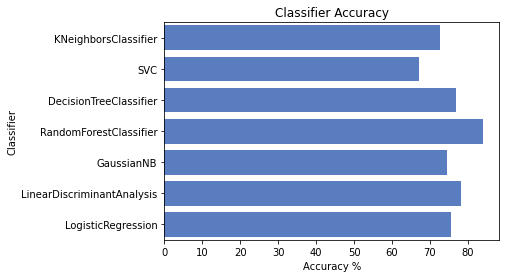

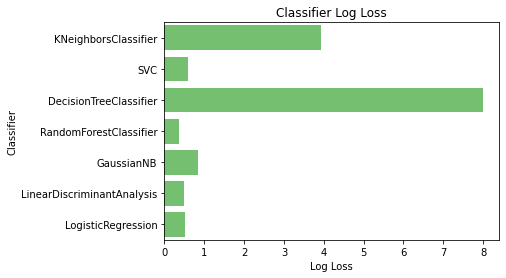

In [ ]:
sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log, color="b")

plt.xlabel('Accuracy %')
plt.title('Classifier Accuracy')
plt.show()

sns.set_color_codes("muted")
sns.barplot(x='Log Loss', y='Classifier', data=log, color="g")

plt.xlabel('Log Loss')
plt.title('Classifier Log Loss')
plt.show()

In [ ]:
# Predict Test Set
favorite_clf = RandomForestClassifier()
favorite_clf.fit(x_train, y_train)
test_predictions = favorite_clf.predict_proba(x_test)

# Format DataFrame
submission = pd.DataFrame(test_predictions)

submission.reset_index()

# Export Submission
#submission.to_csv('submission.csv', index = False)
submission.tail()

,0,1
2786,0.37,0.63
2787,0.09,0.91
2788,0.63,0.37
2789,0.85,0.15
2790,0.44,0.56
